In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tqdm.notebook as tqdm
sns.set()

In [19]:
data_path = '/home/dink/Documents/Research/data/wildfire_case_studies/Holiday_Farm_Year/'
files = os.listdir(data_path)
csv_files = list(filter(lambda f: f.endswith('.csv'), files))
csv_files = list(filter(lambda f: "Primary" in f, files))

In [20]:
dfs = []
for f in csv_files:
    csv = pd.read_csv(os.path.join(data_path, f), usecols=['created_at', 'PM2.5_ATM_ug/m3'])
    dfs.append(csv)
    print(csv.shape)
    print(csv.loc[:, 'created_at'].values[-1])
    print(f)
    #print(csv.isnull().sum())
len(dfs)

(57142, 2)
2021-01-01 23:45:00 UTC
LRAPA-Office Outside (outside) (44.046284 -123.011802) Primary 15_minute_average 01_01_2020 01_01_2021.csv
(55974, 2)
2021-01-01 23:45:00 UTC
PPPM - Crescent Park B (undefined) (44.095686 -123.053352) Primary 15_minute_average 01_01_2020 01_01_2021.csv
(58032, 2)
2021-01-01 23:45:00 UTC
LRAPA-Springfield City Hall B (undefined) (44.046736 -123.017797) Primary 15_minute_average 01_01_2020 01_01_2021.csv
(56227, 2)
2020-12-28 21:00:00 UTC
LRAPA-Springfield HS (outside) (44.053634 -123.013174) Primary 15_minute_average 01_01_2020 01_01_2021.csv
(56032, 2)
2021-01-01 23:45:00 UTC
LRAPA-Walterville Elementary (outside) (44.078845 -122.761444) Primary 15_minute_average 01_01_2020 01_01_2021.csv
(56909, 2)
2021-01-01 23:45:00 UTC
LRAPA-Office Inside (inside) (44.046369 -123.012186) Primary 15_minute_average 01_01_2020 01_01_2021.csv
(56227, 2)
2020-12-28 21:00:00 UTC
LRAPA-Springfield HS B (undefined) (44.053634 -123.013174) Primary 15_minute_average 01_01_2

24

In [21]:
keep_dfs = []
for i, df in enumerate(dfs):
    start_date = pd.to_datetime(df.loc[:, 'created_at'].values[0])
    print(start_date)
    if start_date == pd.to_datetime("2020-01-01 00:00:00+00:00"):
        print("Keep")
        keep_dfs.append(df)
len(keep_dfs)

2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep
2020-01-01 00:00:00+00:00
Keep


24

In [22]:
earliest_end_date = pd.to_datetime("2021-01-01 00:00:00")
for i, df in enumerate(keep_dfs):
    print(i)
    df.loc[:, 'created_at'] = pd.to_datetime(df.loc[:, 'created_at'].values)
    start_date = pd.to_datetime(df.loc[:, 'created_at'].values[0])
    end_date = pd.to_datetime(df.loc[:, 'created_at'].values[-1])
    if end_date < earliest_end_date:
        earliest_end_date = end_date

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23


In [23]:
earliest_end_date

Timestamp('2020-09-08 02:45:00')

In [24]:
# for i, df in enumerate(keep_dfs):
#     indxs = df['created_at'].values <= earliest_end_date
#     keep_dfs[i] = df[indxs]

In [25]:
for i, df in enumerate(keep_dfs):
    keep_dfs[i] = df.set_index('created_at')
    keep_dfs[i].index = keep_dfs[i].index.tz_localize(None)
    keep_dfs[i] = keep_dfs[i][~keep_dfs[i].index.duplicated(keep='first')]

In [26]:
for i, df in enumerate(keep_dfs):
    print(keep_dfs[i].shape)

(34763, 1)
(34194, 1)
(35232, 1)
(34108, 1)
(34208, 1)
(34677, 1)
(34108, 1)
(35232, 1)
(34194, 1)
(32864, 1)
(24041, 1)
(35232, 1)
(21537, 1)
(35232, 1)
(34678, 1)
(32861, 1)
(35232, 1)
(32776, 1)
(32776, 1)
(35232, 1)
(24041, 1)
(34763, 1)
(21537, 1)
(34208, 1)


In [27]:
temp = keep_dfs[0].join(keep_dfs[1], how='outer', lsuffix='_1', rsuffix='_2')
for i in range(2, len(keep_dfs)):
    temp = temp.join(keep_dfs[i], how='outer', lsuffix='_{}'.format(i), rsuffix='_{}'.format(i+1))
temp = temp[~temp.index.duplicated(keep='first')]
temp

,PM2.5_ATM_ug/m3_1,PM2.5_ATM_ug/m3_2,PM2.5_ATM_ug/m3_3,PM2.5_ATM_ug/m3_4,PM2.5_ATM_ug/m3_5,PM2.5_ATM_ug/m3_6,PM2.5_ATM_ug/m3_7,PM2.5_ATM_ug/m3_8,PM2.5_ATM_ug/m3_9,PM2.5_ATM_ug/m3_10,...,PM2.5_ATM_ug/m3_15,PM2.5_ATM_ug/m3_16,PM2.5_ATM_ug/m3_17,PM2.5_ATM_ug/m3_18,PM2.5_ATM_ug/m3_19,PM2.5_ATM_ug/m3_20,PM2.5_ATM_ug/m3_21,PM2.5_ATM_ug/m3_22,PM2.5_ATM_ug/m3_23,PM2.5_ATM_ug/m3_24
created_at,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,15.62,1.94,16.10,12.84,5.75,1.86,15.50,4.94,1.93,1.74,...,1.87,0.0,22.53,14.38,11.01,28.07,9.13,14.77,2.53,6.19
2020-01-01 00:15:00,11.17,2.69,11.70,12.60,6.40,2.28,15.62,5.35,3.12,1.88,...,2.32,0.0,15.64,12.96,9.92,14.87,12.84,11.15,4.39,6.84
2020-01-01 00:30:00,6.10,4.97,4.70,6.57,6.88,2.40,15.89,4.55,5.08,2.05,...,2.50,0.0,24.16,13.66,9.86,22.13,24.81,5.74,2.36,7.66
2020-01-01 00:45:00,8.22,5.16,5.37,12.95,2.51,2.17,31.90,4.35,5.63,4.77,...,2.32,0.0,13.88,14.61,10.85,12.59,20.28,8.04,1.50,2.73
2020-01-01 01:00:00,7.66,7.36,7.98,7.12,2.46,2.27,27.99,10.37,7.09,5.28,...,2.40,0.0,5.89,7.22,5.49,5.54,22.89,7.91,0.62,2.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-01-01 22:45:00,0.04,0.15,0.10,NaN,0.07,0.00,NaN,0.03,0.08,NaN,...,0.00,NaN,0.43,0.00,5.43,0.08,NaN,3912.80,10.91,0.14
2021-01-01 23:00:00,0.15,0.13,0.37,NaN,0.04,0.00,NaN,0.00,0.07,NaN,...,0.00,NaN,0.18,0.00,2.61,0.00,NaN,3927.82,0.19,0.08
2021-01-01 23:15:00,0.29,0.36,1.45,NaN,0.81,0.00,NaN,1.76,0.28,NaN,...,0.00,NaN,0.16,0.02,1.80,0.03,NaN,3933.72,0.15,0.80


In [28]:
full_data = temp.interpolate(method='linear')
full_data.isnull().sum()

PM2.5_ATM_ug/m3_1     0
PM2.5_ATM_ug/m3_2     0
PM2.5_ATM_ug/m3_3     0
PM2.5_ATM_ug/m3_4     0
PM2.5_ATM_ug/m3_5     0
PM2.5_ATM_ug/m3_6     0
PM2.5_ATM_ug/m3_7     0
PM2.5_ATM_ug/m3_8     0
PM2.5_ATM_ug/m3_9     0
PM2.5_ATM_ug/m3_10    0
PM2.5_ATM_ug/m3_11    0
PM2.5_ATM_ug/m3_12    0
PM2.5_ATM_ug/m3_13    0
PM2.5_ATM_ug/m3_14    0
PM2.5_ATM_ug/m3_15    0
PM2.5_ATM_ug/m3_16    0
PM2.5_ATM_ug/m3_17    0
PM2.5_ATM_ug/m3_18    0
PM2.5_ATM_ug/m3_19    0
PM2.5_ATM_ug/m3_20    0
PM2.5_ATM_ug/m3_21    0
PM2.5_ATM_ug/m3_22    0
PM2.5_ATM_ug/m3_23    0
PM2.5_ATM_ug/m3_24    0
dtype: int64

In [29]:
full_data.max(axis=0)

PM2.5_ATM_ug/m3_1      900.04
PM2.5_ATM_ug/m3_2      887.88
PM2.5_ATM_ug/m3_3      841.08
PM2.5_ATM_ug/m3_4      725.32
PM2.5_ATM_ug/m3_5      655.83
PM2.5_ATM_ug/m3_6      354.52
PM2.5_ATM_ug/m3_7     4886.76
PM2.5_ATM_ug/m3_8      622.77
PM2.5_ATM_ug/m3_9      877.71
PM2.5_ATM_ug/m3_10     767.03
PM2.5_ATM_ug/m3_11     228.18
PM2.5_ATM_ug/m3_12     675.70
PM2.5_ATM_ug/m3_13     236.06
PM2.5_ATM_ug/m3_14     815.04
PM2.5_ATM_ug/m3_15     344.63
PM2.5_ATM_ug/m3_16       0.00
PM2.5_ATM_ug/m3_17    1338.40
PM2.5_ATM_ug/m3_18     622.73
PM2.5_ATM_ug/m3_19    4275.68
PM2.5_ATM_ug/m3_20    3628.17
PM2.5_ATM_ug/m3_21     241.04
PM2.5_ATM_ug/m3_22    4827.95
PM2.5_ATM_ug/m3_23     236.66
PM2.5_ATM_ug/m3_24     710.09
dtype: float64

In [30]:
full_data.min(axis=0)

PM2.5_ATM_ug/m3_1     0.0
PM2.5_ATM_ug/m3_2     0.0
PM2.5_ATM_ug/m3_3     0.0
PM2.5_ATM_ug/m3_4     0.0
PM2.5_ATM_ug/m3_5     0.0
PM2.5_ATM_ug/m3_6     0.0
PM2.5_ATM_ug/m3_7     0.0
PM2.5_ATM_ug/m3_8     0.0
PM2.5_ATM_ug/m3_9     0.0
PM2.5_ATM_ug/m3_10    0.0
PM2.5_ATM_ug/m3_11    0.0
PM2.5_ATM_ug/m3_12    0.0
PM2.5_ATM_ug/m3_13    0.0
PM2.5_ATM_ug/m3_14    0.0
PM2.5_ATM_ug/m3_15    0.0
PM2.5_ATM_ug/m3_16    0.0
PM2.5_ATM_ug/m3_17    0.0
PM2.5_ATM_ug/m3_18    0.0
PM2.5_ATM_ug/m3_19    0.0
PM2.5_ATM_ug/m3_20    0.0
PM2.5_ATM_ug/m3_21    0.0
PM2.5_ATM_ug/m3_22    0.0
PM2.5_ATM_ug/m3_23    0.0
PM2.5_ATM_ug/m3_24    0.0
dtype: float64

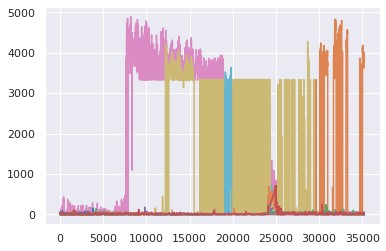

In [31]:
plt.plot(full_data.values);

In [32]:
full_data_clean = full_data.drop(['PM2.5_ATM_ug/m3_7', 'PM2.5_ATM_ug/m3_16', 'PM2.5_ATM_ug/m3_19', 'PM2.5_ATM_ug/m3_20', 
                                  'PM2.5_ATM_ug/m3_22'], axis=1)

In [33]:
full_data_clean_vals = full_data_clean.values

In [237]:
full_data_clean_vals[np.where(full_data_clean_vals == 0)] = 1e-5

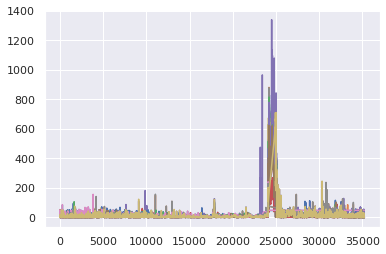

In [34]:
plt.plot(full_data_clean_vals);

<AxesSubplot:>

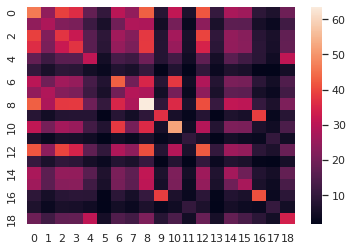

In [241]:
sns.heatmap(np.cov(full_data_clean_vals[:20000, :].T))

In [233]:
full_data_clean_vals = pd.DataFrame(np.log(full_data_clean_vals)).diff().values[1:, :]

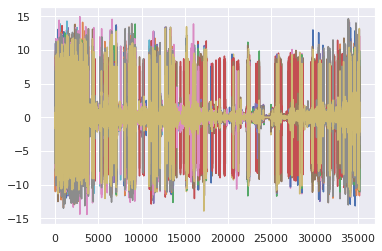

In [234]:
plt.plot(full_data_clean_vals);

In [215]:
from statsmodels.tsa.tsatools import detrend

#full_data_clean_detrend = detrend(full_data_clean_vals, order=2, axis=0)

In [35]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
#scaler = MinMaxScaler()
full_data_clean_scaled = scaler.fit_transform(full_data_clean_vals)
#full_data_clean_scaled = scaler.fit_transform(np.log(full_data_clean_vals))

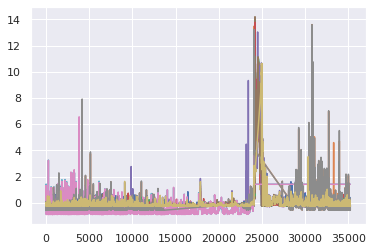

In [36]:
plt.plot(full_data_clean_scaled);

In [37]:
resid_df = pd.DataFrame(full_data_clean_scaled)

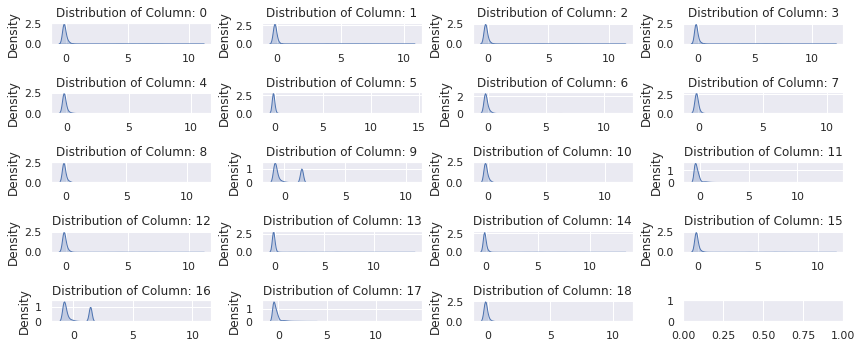

In [38]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(12, 5), sharex=False, sharey=False)
axes = axes.ravel()  # array to 1D
cols = resid_df.columns  # create a list of dataframe columns to use

for col, ax in zip(cols, axes):
    data = resid_df[[col]]  # select the data
    sns.kdeplot(data=data, x=col, shade=True, ax=ax)
    ax.set(title=f'Distribution of Column: {col}', xlabel=None)
    
fig.tight_layout()
plt.show()

In [39]:
np.savetxt('../../data/holiday_farm_clean.csv', resid_df.values, delimiter=",")

<AxesSubplot:>

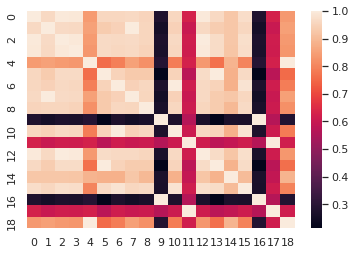

In [58]:
sns.heatmap(np.corrcoef(full_data_clean.values.T))

<AxesSubplot:>

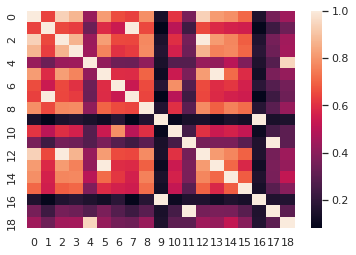

In [59]:
sns.heatmap(np.corrcoef(full_data_clean.values[0:15000].T))

<AxesSubplot:>

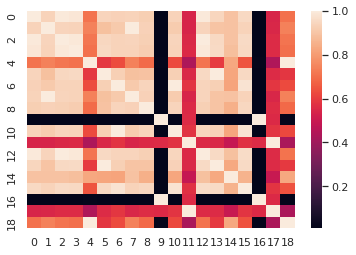

In [60]:
sns.heatmap(np.corrcoef(full_data_clean.values[24000:26000].T))

<AxesSubplot:>

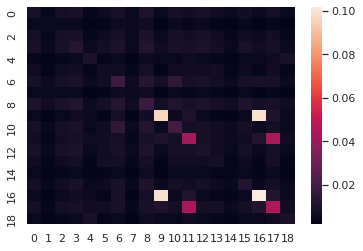

In [53]:
sns.heatmap(np.cov(resid_df.values[0:15000, :].T))

<AxesSubplot:>

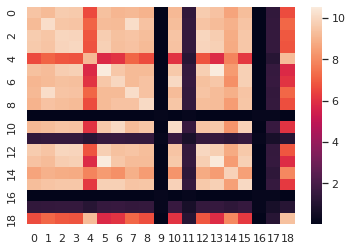

In [41]:
sns.heatmap(np.cov(resid_df.values[24000:26000, :].T))

In [106]:
full_data_clean_scaled.shape

(35232, 19)

<AxesSubplot:>

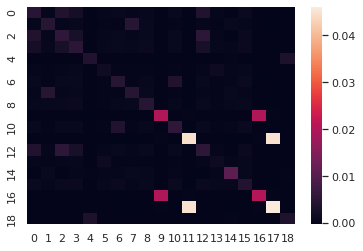

In [43]:
sns.heatmap(np.cov(resid_df.diff().values[1:, :].T))

<AxesSubplot:>

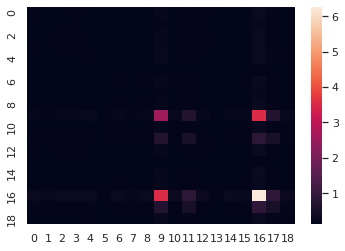

In [51]:
r_vals = resid_df.values
r_vals += np.abs(r_vals.min())
r_vals[r_vals==0] = 1e-6
sns.heatmap(np.cov(np.log(r_vals).T))